In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [35]:
discharge_data = pd.read_csv("../../dataset/processed/discharge_data.csv")

discharge_05 = discharge_data[discharge_data["battery_id"] == "B0005"].copy()
discharge_06 = discharge_data[discharge_data["battery_id"] == "B0006"].copy()
discharge_07 = discharge_data[discharge_data["battery_id"] == "B0007"].copy()
discharge_18 = discharge_data[discharge_data["battery_id"] == "B0018"].copy()

In [37]:
def plot_discharge_capacity_over_cycles(discharge_data, battery_ids):
    plt.figure(figsize=(10, 5))
    colors = plt.cm.get_cmap("tab10", len(battery_ids))

    for i, battery_id in enumerate(battery_ids):
        discharge_battery = discharge_data[discharge_data["battery_id"] == battery_id].copy()

        if discharge_battery.empty:
            print(f"Warning: No discharge data found for battery {battery_id}")
            continue

        temperature = discharge_battery["ambient_temperature"].iloc[0]

        initial_capacity = discharge_battery["Capacity"].iloc[0]
        threshold_capacity = initial_capacity * 0.7

        plt.plot(
            discharge_battery["cycle_number"], discharge_battery["Capacity"],
            linestyle="-", label=f"Battery {battery_id}", color=colors(i), linewidth=1.5
        )

        plt.axhline(y=threshold_capacity, color=colors(i), linestyle="--", linewidth=1.2, label="70% Capacity Threshold")

    plt.xlabel("Cycle Number")
    plt.ylabel("Discharge Capacity")
    plt.title("Battery Capacity Degradation Over Cycles (24°C)")
    plt.legend(title="Battery ID")
    plt.grid(True)

    plt.show()

C:\Users\HLC\AppData\Local\Temp\ipykernel_17332\3877614335.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab10", len(battery_ids))


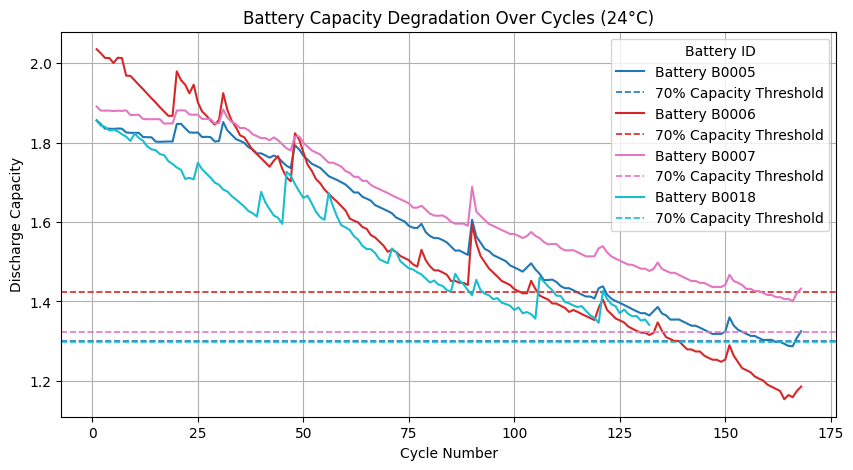

In [38]:
battery_list = ["B0005", "B0006", "B0007", "B0018"]
plot_discharge_capacity_over_cycles(discharge_data, battery_list)

### Discharge voltage measured of battery B0005 at different cycles

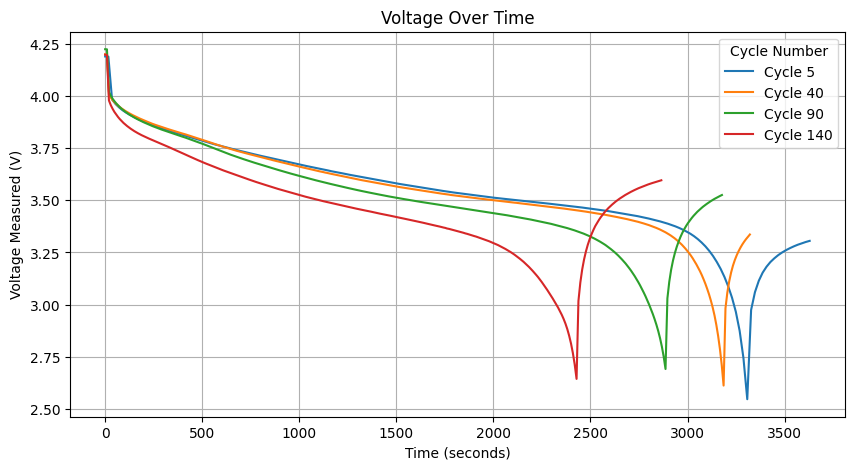

In [39]:
selected_cycles = [5, 40, 90, 140]

selected_rows = discharge_05[discharge_05["cycle_number"].isin(selected_cycles)]

plt.figure(figsize=(10, 5))

for _, row in selected_rows.iterrows():
    file_path = f"../../dataset/processed/data/{row['filename']}"
    cycle_number = row["cycle_number"]

    df = pd.read_csv(file_path)

    plt.plot(df["Time"], df["Voltage_measured"], label=f"Cycle {cycle_number}")

plt.xlabel("Time (seconds)")
plt.ylabel("Voltage Measured (V)")
plt.title(f"Voltage Over Time")
plt.legend(title="Cycle Number")
plt.grid(True)

plt.show()

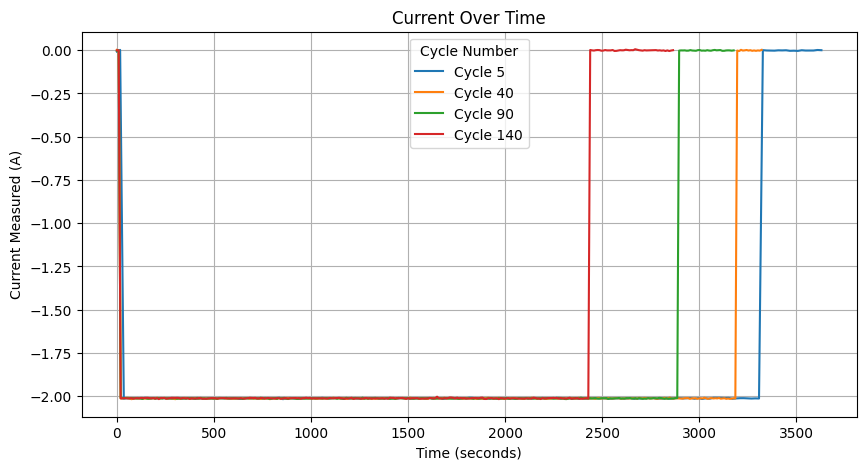

In [40]:
plt.figure(figsize=(10, 5))

for _, row in selected_rows.iterrows():
    file_path = f"../../dataset/processed/data/{row['filename']}"
    cycle_number = row["cycle_number"]

    df = pd.read_csv(file_path)

    plt.plot(df["Time"], df["Current_measured"], label=f"Cycle {cycle_number}")

plt.xlabel("Time (seconds)")
plt.ylabel("Current Measured (A)")
plt.title(f"Current Over Time")
plt.legend(title="Cycle Number")
plt.grid(True)

plt.show()

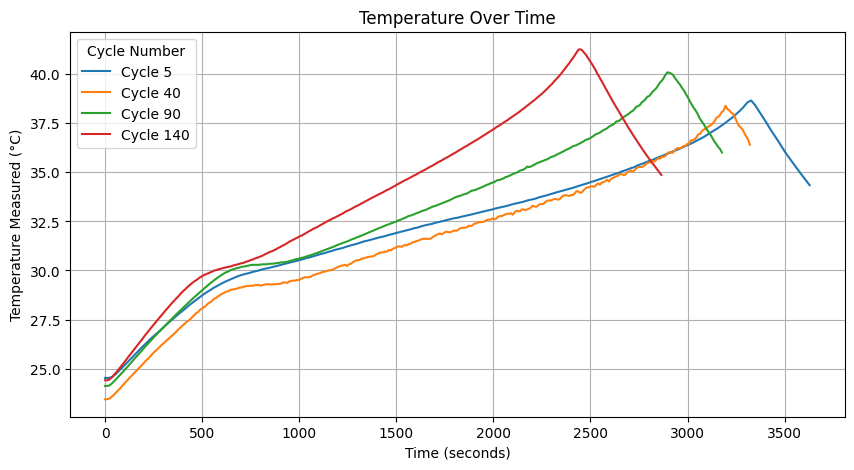

In [41]:
plt.figure(figsize=(10, 5))

for _, row in selected_rows.iterrows():
    file_path = f"../../dataset/processed/data/{row['filename']}"
    cycle_number = row["cycle_number"]

    df = pd.read_csv(file_path)

    plt.plot(df["Time"], df["Temperature_measured"], label=f"Cycle {cycle_number}")

plt.xlabel("Time (seconds)")
plt.ylabel("Temperature Measured (°C)")
plt.title(f"Temperature Over Time")
plt.legend(title="Cycle Number")
plt.grid(True)

plt.show()

## Impedance

In [42]:
impedance_data = pd.read_csv("../../dataset/processed/impedance_data.csv")

impedance_05 = impedance_data[impedance_data["battery_id"] == "B0005"].copy()

In [43]:
def plot_resistance_over_cycles(impedance_data, battery_ids):
    plt.figure(figsize=(10, 5))
    colors = plt.cm.get_cmap("tab10", len(battery_ids))

    for i, battery_id in enumerate(battery_ids):
        battery = impedance_data[impedance_data["battery_id"] == battery_id].copy()

        if battery.empty:
            print(f"Warning: No data found for battery {battery_id}")
            continue

        plt.plot(
            battery["cycle_number"], battery["Rint"],
            linestyle="-", label=f"Battery {battery_id}", color=colors(i), linewidth=1.5
        )

    plt.xlabel("Cycle Number")
    plt.ylabel("Internal Resistance")
    plt.title("Internal Resistance Over Cycles")
    plt.legend(title="Battery ID", bbox_to_anchor=(1.05, 1), loc="best")
    plt.grid(True)

    plt.show()

C:\Users\HLC\AppData\Local\Temp\ipykernel_17332\3252591060.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab10", len(battery_ids))


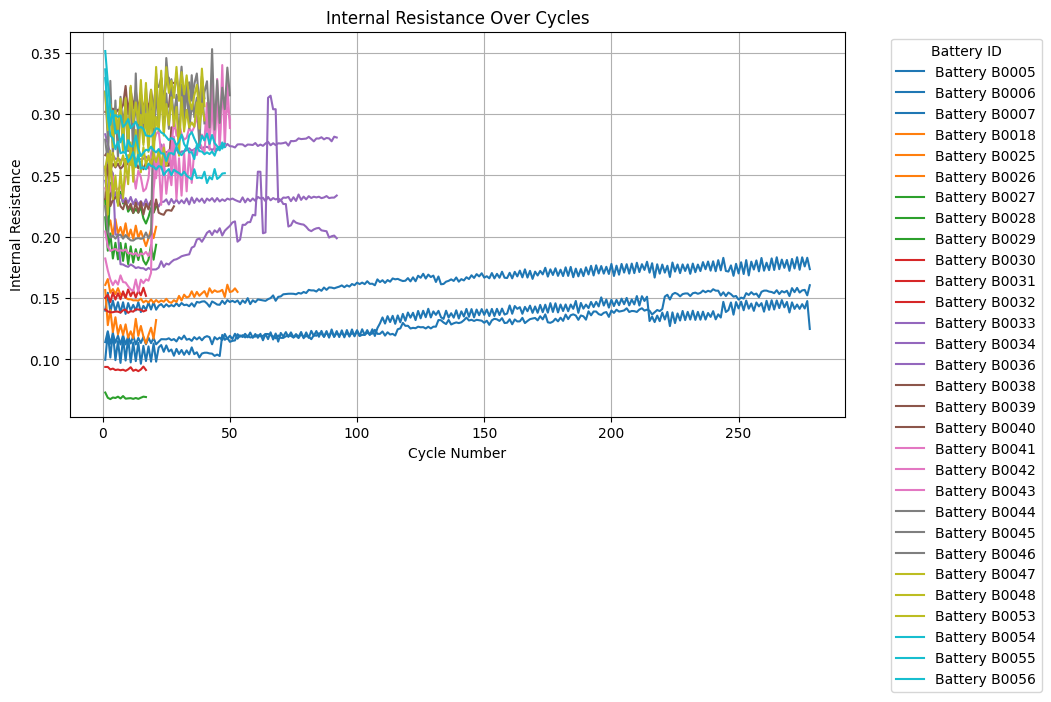

In [44]:
battery_list = impedance_data["battery_id"].unique()
plot_resistance_over_cycles(impedance_data, battery_list)

## RUL Prediction

### How: Used the first 50 cycles of a battery to predict the capacity in the next cycles